# MiBiReMo Example 6: validation against mibitrans

With `phreeqc_coupling=True`, `FieldModel` builds a reactive transport model by coupling MODFLOW 6 with PHREEQC.
MODFLOW 6 simulates the flow and transports of the components of the PHREEQC solutions (one GWT model per component),
while PHREEQC computes the reactions in every cell at every time step. The coupling is obtained using
[mf6rtm](https://github.com/p-ortega/mf6rtm) package.

This example validates the transport and the PHREEQC coupling against the exact analytical solution from the
[mibitrans](https://github.com/MiBiPreT/mibitrans) package (`pip install mibitrans`) for a plume from a
constant-concentration source in uniform flow, for a conservative tracer. In PHREEQC, this is represented by defining
an aqueous pseudo-component Tr with first-order decay.

MODFLOW 6 and its library are required for this example: `get-modflow :python --subset mf6,libmf6`.

In [1]:
import math
from importlib.resources import files
from pathlib import Path
import flopy
import matplotlib.pyplot as plt
import mibitrans as mbt
import numpy as np
import shapely
from matplotlib.patches import Patch
from mf6rtm.mup3d.base import ChemStress
from mibitrans.analysis.differences import rmse
import mibiremo as mb

DAY = 86400.0
OUTPUT = (Path(__file__).parent if "__file__" in globals() else Path()) / "output"  # next to this script or notebook
OUTPUT.mkdir(exist_ok=True)

## Definition of the tracer pseudo-component (Tr) in PHREEQC

Kinetic rates must be defined in the RATES block of the database. Here `phreeqc.dat` is extended with an element
Tr (master species Tr, gram formula weight 1) and a rate "Tr" for first-order decay, r = λ C, with λ = `PARM(1)`
[s⁻¹]. The KINETICS reactant "Tr" with formula `Tr -1` removes Tr from the solution.

In [2]:
definitions = """
SOLUTION_MASTER_SPECIES
Tr       Tr       0     Tr     1.0
SOLUTION_SPECIES
Tr = Tr
    log_k 0
RATES
Tr
-start
10 SAVE PARM(1) * TOT("Tr") * TIME
-end
"""
text = (files("mibiremo") / "database" / "phreeqc.dat").read_text(encoding="latin-1")
database = OUTPUT / "decay.dat"
database.write_text(text.replace("\nEND\n", definitions + "END\n", 1), encoding="latin-1")


def decay_kinetics(half_life):
    """KINETICS block of first-order decay of Tr with half-life half_life [s]."""
    return {"Tr": {"m0": 1.0, "parms": [math.log(2) / half_life], "formula": "Tr -1"}}

## Model

Uniform flow along +x with seepage velocity v = K i / n = 0.69 m/d, longitudinal and transverse dispersivities
α_L = 1 m and α_T = 0.1 m, no pumping. The source is a column of cells at x = 0 with a constant concentration
C₀, 5.5 m wide, over the full aquifer thickness. Wells with Q = 0 place the domain and serve as observation
points on the plume centreline. The grid has uniform 0.5 m cells and the TVD advection scheme keeps the numerical
dispersion small.

In [3]:
conductivity, gradient, porosity = 2e-4, 0.01, 0.25  # K [m s-1], i [-], n [-]
alpha_l, alpha_t = 1.0, 0.1  # dispersivities [m]
half_life = 10 * DAY

screen = {"well_top": 10.0, "well_bottom": 0.0, "diameter": 0.05, "screen_top": 10.0, "screen_bottom": 0.0}
positions = {"SOURCE": 0.0, "X_5": 5.0, "X_10": 10.0, "X_20": 20.0}
points = [mb.Well(name, x=x, y=0.0, **screen) for name, x in positions.items()]
uniform_flow = {
    "wells": points,
    "flow_rates": {name: 0.0 for name in positions},
    "domain_size": (50.5, 24.5),  # cell faces on the boundary: uniform cells
    "top": 10.0,
    "bottom": 0.0,
    "hydraulic_conductivity": conductivity,
    "porosity": porosity,
    "reference_head": 10.0,
    "regional_hydraulic_gradient": gradient,
    "regional_flow_azimuth": 90.0,  # towards +x
    "advection_scheme": "tvd",
    "dispersion": True,
    "longitudinal_dispersivity": alpha_l,
    "transverse_dispersivity": alpha_t,
    "grid_spacing": 0.5,
    "grid_spacing_at_wells": 0.5,
    "simulation_time": 30 * DAY,
    "time_step": 0.5 * DAY,
}
plume = mb.FieldModel(workspace=OUTPUT / "ex6_validation_vs_mibitrans", **uniform_flow)
source = list(zip(*np.nonzero(plume.zone(shapely.box(-0.1, -2.6, 0.1, 2.6)))))  # 11 cells of 0.5 m

**Model setup.** `build` creates the grid and the flopy simulation without running it. Constant-head (CHD) cells
on the lateral boundaries impose the regional hydraulic gradient; the water entering through them has C = 0.

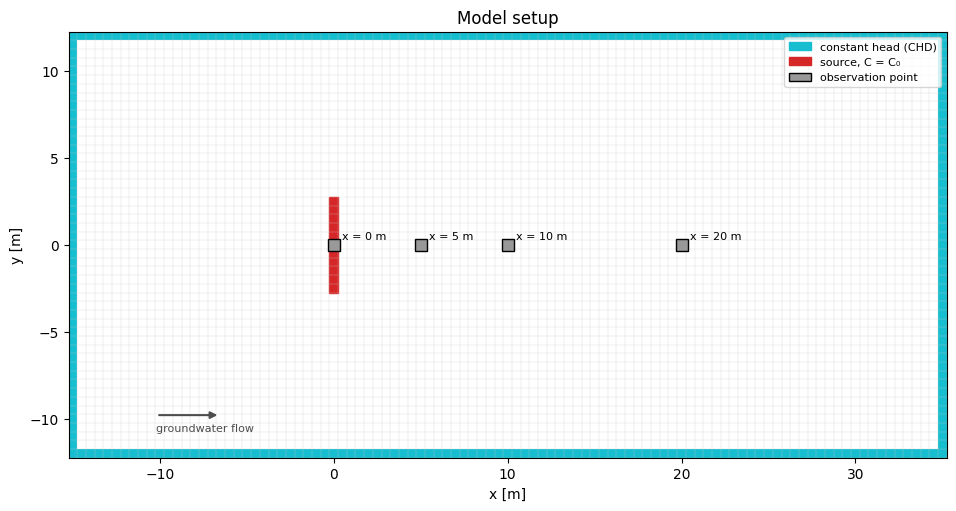

In [4]:
plume.build()
fig, ax = plt.subplots(figsize=(10, 5), layout="constrained")
view = flopy.plot.PlotMapView(model=plume.simulation.get_model("gwf"), ax=ax)
view.plot_grid(lw=0.2, color="0.8")
view.plot_bc("CHD", color="tab:cyan")
for _, i, j in source:
    ax.fill(*zip(*plume.grid.get_cell_vertices(i, j)), color="tab:red")
mb.plotting.wells(ax, points, labels=False)
for w in points:
    ax.annotate(f"x = {w.x:g} m", (w.x, w.y), textcoords="offset points", xytext=(6, 4), fontsize=8)
mb.plotting.flow_arrow(ax, 90.0)
handles = [
    Patch(color="tab:cyan", label="constant head (CHD)"),
    Patch(color="tab:red", label="source, C = C₀"),
    Patch(facecolor="0.6", edgecolor="k", label="observation point"),
]
ax.legend(handles=handles, loc="upper right", fontsize=8)
ax.set(xlabel="x [m]", ylabel="y [m]", title="Model setup")
plt.show()

**Conservative tracer.** The source is a constant-concentration (CNC) package added to the tracer model of the
flopy simulation, C₀ = 1.

In [5]:
flopy.mf6.ModflowGwtcnc(plume.simulation.get_model("gwt"), stress_period_data=[(cell, 1.0) for cell in source])
plume.run()
times = np.arange(1, 31) * DAY
numerical = {"tracer": np.array([plume.concentration(t)[0] for t in times])}
observations = {"tracer": {name: plume.well_concentration(name) for name in ["X_5", "X_10", "X_20"]}}

**First-order decay.** The same model with `phreeqc_coupling=True` and PHREEQC solutions numbered as in PHREEQC
(concentrations in mol/kgw): solution 1 is the groundwater, solution 2 contains Tr. All cells use KINETICS block 1
(decay of Tr with a half-life of 10 days). The source cells keep solution 2 through an mf6rtm `ChemStress` of type
"cnc", added after `build` to the mf6rtm model `decay.mup3d`. MODFLOW 6 concentrations are in mol/m³.

The pH of the solutions is below 7: pure water at pH 7 and 25 °C has a slightly negative charge balance, which
MODFLOW 6 rejects as a constant concentration.

In [6]:
decay = mb.FieldModel(
    workspace=OUTPUT / "ex6_validation_vs_mibitrans",
    **uniform_flow,
    phreeqc_coupling=True,
    database=database,
    solutions={1: {"pH": 6.5}, 2: {"Tr": 1e-3, "pH": 6.5}},
    kinetics={1: decay_kinetics(half_life)},
    initial_kinetics=1,
)
decay.build()
cnc = ChemStress("cnc", type="cnc")
cnc.set_cells(source)
cnc.set_spd([2] * len(source))
decay.mup3d.set_chem_stress(cnc)
decay.run(n_threads=-1)
print("Components transported by MODFLOW 6:", decay.mup3d.components)

c0 = decay.concentration(component="Tr")[source[0]]
numerical["decay"] = np.array([decay.concentration(t, component="Tr")[0] for t in times]) / c0
observations["decay"] = {}
for name in ["X_5", "X_10", "X_20"]:
    curve = decay.well_concentration(name, component="Tr")
    observations["decay"][name] = curve.assign(concentration=curve["concentration"] / c0)

Initializing ChemStress
ChemStress cnc initialized


Components transported by MODFLOW 6: ['H', 'O', 'Charge', 'Tr']


**mibitrans** computes the same plumes (units m and days), at the cell centres of our grid.

In [7]:
analytical = {}
for name, decay_rate in [("tracer", 0.0), ("decay", math.log(2) / (half_life / DAY))]:
    model = mbt.Mibitrans(
        mbt.HydrologicalParameters(
            h_conductivity=conductivity * DAY, h_gradient=gradient, porosity=porosity, alpha_x=alpha_l, alpha_y=alpha_t
        ),
        mbt.AttenuationParameters(decay_rate=decay_rate),
        mbt.SourceParameters(np.array([len(source) * 0.25]), np.array([1.0]), depth=10.0),
        mbt.ModelParameters(model_length=30.0, model_width=20.0, model_time=30.0, dx=0.5, dy=0.5, dt=1.0),
    )
    analytical[name] = model.run().relative_cxyt  # C / C0 (t, y, x)

titles = {"tracer": "Tracer simulation", "decay": "Tracer + decay simulation"}
xc, yc = plume.grid.xcellcenters[0], plume.grid.ycellcenters[:, 0]
rows, columns = np.ix_([np.argmin(abs(yc - y)) for y in model.y], [np.argmin(abs(xc - x)) for x in model.x])
centre = np.argmin(abs(model.y))

**Plumes at 30 d**, with contours at C/C₀ = 0.1 and 0.5.

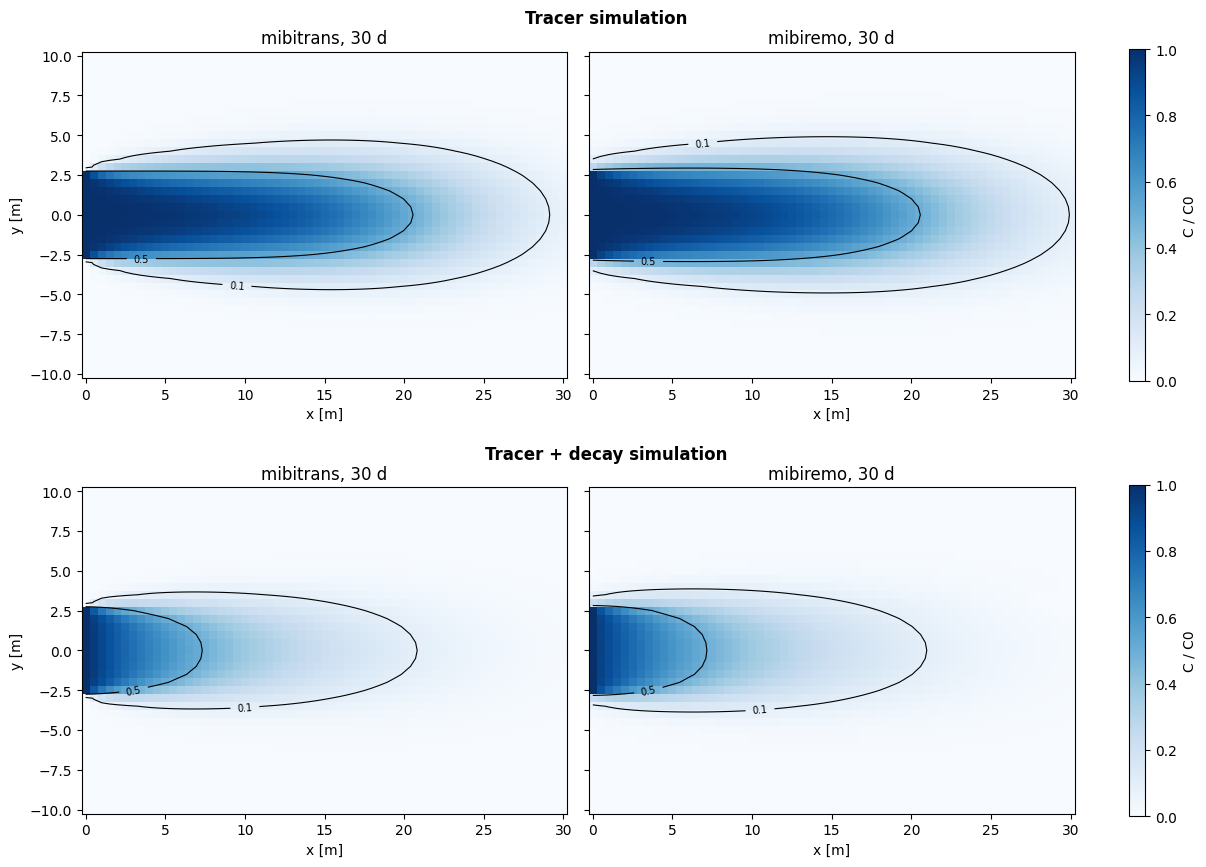

In [8]:
fig = plt.figure(figsize=(12, 8.5), layout="constrained")
for name, subfigure in zip(analytical, fig.subfigures(2, 1, hspace=0.05)):
    subfigure.suptitle(titles[name], fontweight="bold")
    axes = subfigure.subplots(1, 2, sharey=True)
    maps = {"mibitrans": analytical[name][-1], "mibiremo": numerical[name][-1][rows, columns]}
    for ax, (label, values) in zip(axes, maps.items()):
        mesh = ax.pcolormesh(model.x, model.y, values, shading="nearest", cmap="Blues", vmin=0, vmax=1)
        contours = ax.contour(model.x, model.y, values, levels=[0.1, 0.5], colors="k", linewidths=0.8)
        ax.clabel(contours, fontsize=7)
        ax.set(title=f"{label}, {model.t[-1]:g} d", xlabel="x [m]", aspect="equal")
    axes[0].set_ylabel("y [m]")
    subfigure.colorbar(mesh, ax=axes, label="C / C0")
plt.show()

Tracer simulation: root-mean-square difference of C/C0 = 0.030
Tracer + decay simulation: root-mean-square difference of C/C0 = 0.020


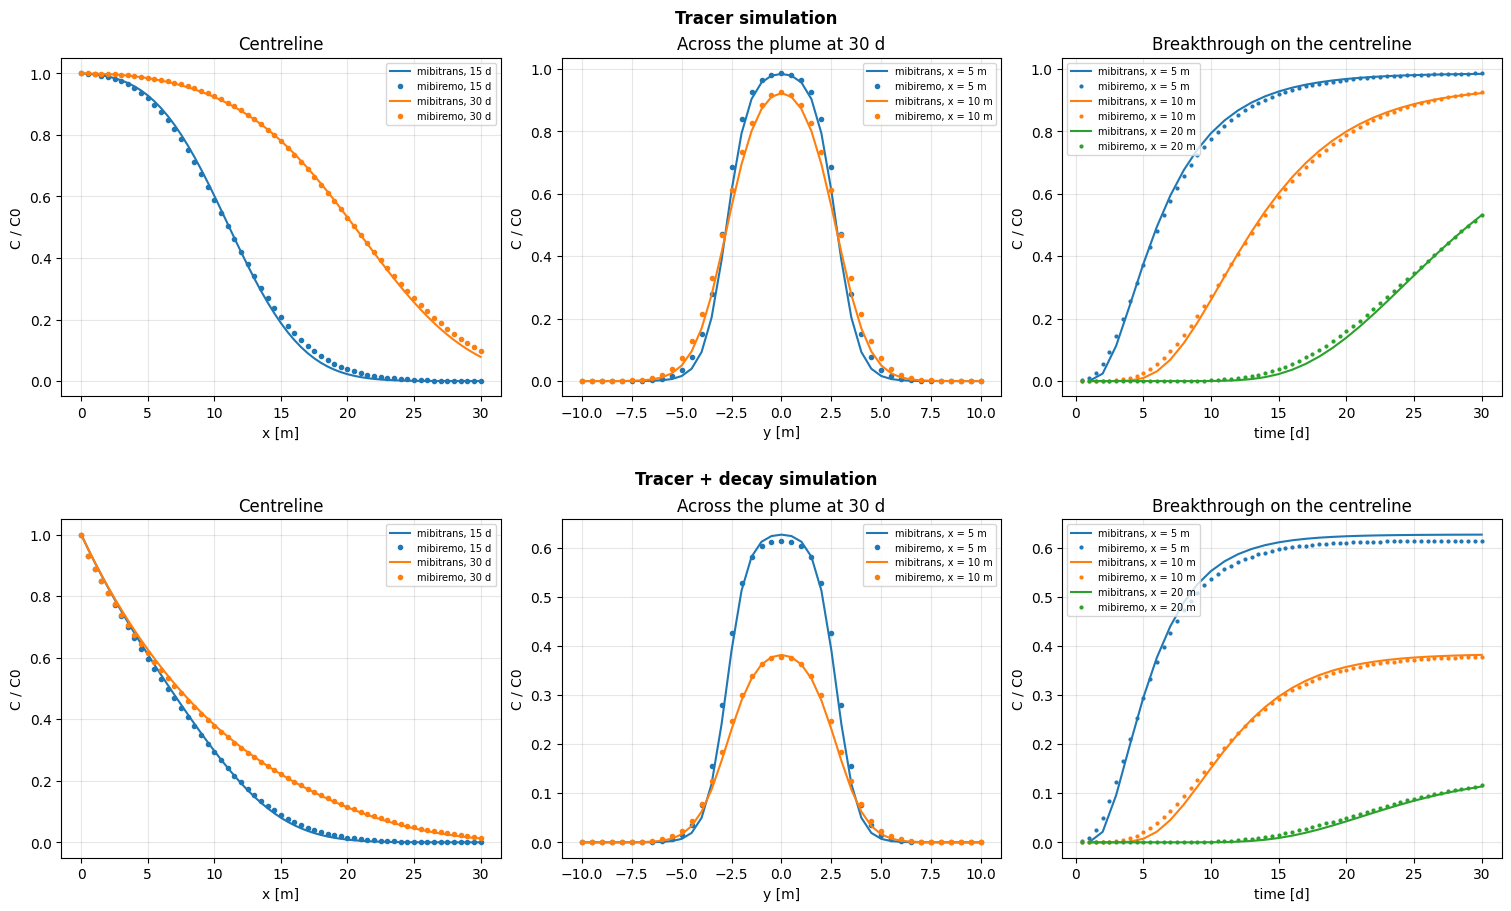

In [9]:
fig = plt.figure(figsize=(15, 9), layout="constrained")
for name, subfigure in zip(analytical, fig.subfigures(2, 1, hspace=0.05)):
    analytical_sim, mibiremo_sim = analytical[name], numerical[name][:, rows, columns]
    # x > 0: mibitrans has C = 0 at x = 0
    error = rmse(analytical_sim[:, :, 1:], mibiremo_sim[:, :, 1:], concentration_cutoff=0.01)
    print(f"{titles[name]}: root-mean-square difference of C/C0 = {error:.3f}")
    subfigure.suptitle(titles[name], fontweight="bold")
    axes = subfigure.subplots(1, 3)
    for k, color in [(14, "tab:blue"), (29, "tab:orange")]:
        axes[0].plot(model.x, analytical_sim[k, centre], color=color, label=f"mibitrans, {model.t[k]:g} d")
        axes[0].plot(model.x, mibiremo_sim[k, centre], "o", color=color, ms=3, label=f"mibiremo, {model.t[k]:g} d")
    for x, color in [(5.0, "tab:blue"), (10.0, "tab:orange")]:
        j = np.argmin(abs(model.x - x))
        axes[1].plot(model.y, analytical_sim[-1, :, j], color=color, label=f"mibitrans, x = {x:g} m")
        axes[1].plot(model.y, mibiremo_sim[-1, :, j], "o", color=color, ms=3, label=f"mibiremo, x = {x:g} m")
    for (well, curve), color in zip(observations[name].items(), ["tab:blue", "tab:orange", "tab:green"]):
        x = positions[well]
        j = np.argmin(abs(model.x - x))
        axes[2].plot(model.t, analytical_sim[:, centre, j], color=color, label=f"mibitrans, x = {x:g} m")
        label = f"mibiremo, x = {x:g} m"
        axes[2].plot(curve["time"] / DAY, curve["concentration"], "o", color=color, ms=2, label=label)
    axes[0].set(title="Centreline", xlabel="x [m]", ylabel="C / C0")
    axes[1].set(title="Across the plume at 30 d", xlabel="y [m]", ylabel="C / C0")
    axes[2].set(title="Breakthrough on the centreline", xlabel="time [d]", ylabel="C / C0")
    for ax in axes:
        ax.grid(alpha=0.3)
        ax.legend(fontsize=7)
plt.show()